# Comprehensive analysis of the Customer Personality Analysis dataset: from normalization to statistical hypothesis testing

## 1. Introduction
The project was completed by 4th semester student Matviy Antipov (Innovation Campus NTU KhPI, Python course) on the instructions of Prof. Sokol.

### 1.1. Description of the subject area and purpose of the analysis
The work solves the problem of customer retention. In my pipeline the hypothesis H_{0} will be proved or disproved.

### 1.2. Plan of the work
(1) Data Preparation & Feature Engineering [Pandas, StandardScaler] $\to$ (2) Customer Segmentation [K-Means Clustering] $\to$ (3) Target Group Identification [EDA, Cluster Profiling] $\to$ (4) Distribution Analysis [Shapiro-Wilk Test] $\to$ (5) Statistical Hypothesis Testing [T-test / Mann-Whitney U] $\to$ (6) Business Insights & Retention Strategy

### 1.3. Overview of the data set structure

The "***Customer Personality Analysis***" dataset provides a comprehensive, multidimensional snapshot of a company's customer base. Based on the provided metadata and preliminary inspection, the dataset consists of features that have already undergone initial preprocessing (such as One-Hot Encoding for categorical variables and Feature Engineering).

The variables can be logically categorized into five distinct groups representing different aspects of customer behavior:

1. **Customer Demographics & Household Structure**

*Personal Profile*: Age (derived from birth year), Income (yearly household income).

*Education & Marital Status*: One-hot encoded features representing education levels (education_Basic, education_Graduation, education_Master, education_PhD, etc.) and marital status (marital_Divorced, marital_Married, marital_Single, etc.).

*Household Composition*: Kidhome and Teenhome, indicating the number of children and teenagers in the household.

2. **Customer History & Loyalty**

*Customer_Days*: A derived continuous variable representing the total number of days the customer has been registered with the company.

*Recency*: The number of days since the customer's last purchase.

*Complain*: A binary indicator (1/0) of whether the customer has complained in the last 2 years.

3. **Spending Habits (Product Categories)**

*Amount Spent (**Mnt**...)*: Continuous variables representing the total amount spent over the last 2 years across various categories: MntWines, MntFruits, MntMeatProducts, MntFishProducts, MntSweetProducts, and MntGoldProds.

*Aggregated Metrics*: MntTotal (overall spending volume) and MntRegularProds, which are crucial for assessing the total financial value of a customer.

4. **Purchasing Channels (Place)**

*Metrics indicating the preferred method of shopping*: NumWebPurchases, NumCatalogPurchases, and NumStorePurchases.

*Web engagement* is tracked via NumWebVisitsMonth.

5. **Marketing Campaign Responsiveness (Promotions)**

*Historical Response*: Binary indicators for previous campaigns (AcceptedCmp1 through AcceptedCmp5).

*Discount Hunting*: NumDealsPurchases indicating the number of purchases made specifically with a discount. This feature is the primary metric for our hypothesis regarding the retention of occasional buyers.

*Target Variables*: Response (acceptance of the final campaign) and AcceptedCmpOverall (an aggregated metric of total accepted offers).

## 2. Import and initial data processing
###### *(Technical start: loading CSV using Pandas, checking data types)*

### 2.1. Data loading and variable type analysis
In that part of work all of dataset's data will be downloaded using ***pandas*** and transformed into pd.DataFrame type of data.

---

In [1]:
import pandas as pd

df = pd.read_csv('dataset/ifood_df.csv')
df

,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,...,marital_Together,marital_Widow,education_2n Cycle,education_Basic,education_Graduation,education_Master,education_PhD,MntTotal,MntRegularProds,AcceptedCmpOverall
0,58138.0,0,0,58,635,88,546,172,88,88,...,0,0,0,0,1,0,0,1529,1441,0
1,46344.0,1,1,38,11,1,6,2,1,6,...,0,0,0,0,1,0,0,21,15,0
2,71613.0,0,0,26,426,49,127,111,21,42,...,1,0,0,0,1,0,0,734,692,0
3,26646.0,1,0,26,11,4,20,10,3,5,...,1,0,0,0,1,0,0,48,43,0
4,58293.0,1,0,94,173,43,118,46,27,15,...,0,0,0,0,0,0,1,407,392,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2200,61223.0,0,1,46,709,43,182,42,118,247,...,0,0,0,0,1,0,0,1094,847,0
2201,64014.0,2,1,56,406,0,30,0,0,8,...,1,0,0,0,0,0,1,436,428,1
2202,56981.0,0,0,91,908,48,217,32,12,24,...,0,0,0,0,1,0,0,1217,1193,1
2203,69245.0,0,1,8,428,30,214,80,30,61,...,1,0,0,0,0,1,0,782,721,0


### 2.2. Data cleaning stage


In [2]:
df = df.dropna()
df = df.drop(columns=['Z_CostContact', 'Z_Revenue'])
df = df[(df['Age'] < 100) & (df['Income'] < 200000)]
df = df.drop_duplicates()
df = df.reset_index(drop=True)
print(f"Shape of clean dataset: {df.shape}")
print(f"Null values: {df.isnull().sum().sum()}")

Shape of clean dataset: (2021, 37)
Null values: 0


In that stage following cleaning stages were implemented for dataset, such as:

+ **dropna()** - that function deletes each *Null* value
+ **drop()** - that function was used for deleting some columns, which contain only *constant* values, whithin they can interfere with future clustering using the ***K-Means*** algorithm, as this algorithm is based on *distances*. It is typically critical for algorithms of this type to avoid encountering *non-numeric* values.
+ **drop_duplicates()** - this function was called because during clustering it is not so important for us to save duplicates as it is important to see the numerical or percentage ***skew*** and the ratio of groups.

+ **reset_index(drop=True)** - that is the common final stage of cleaning of the data. All indexes, which contain false numerical values after cleaning will be corrected.

### 3. Feature Selection

Several metrics from a whole dataset are to be selected. 0/1 binary data is not acceptable, so that is neccessary to make a DataFrame, that contain only Euclid values, because the key principle of the algorythm is to compare lengths between points.

In [4]:
from sklearn.preprocessing import StandardScaler

features_for_clustering = [
    'Income', 
    'MntTotal',           #Sum of all purchases
    'Recency',            #Days since last purchase
    'Customer_Days',      #How long the customer has been with us
    'NumDealsPurchases',  #Purchases with discounts
    'NumWebPurchases', 
    'NumCatalogPurchases', 
    'NumStorePurchases'
]

X = df[features_for_clustering]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"Shape: {X_scaled.shape}")
print("First row of scaled data:\n", X_scaled[0])

Shape: (2021, 8)
First row of scaled data:
 [ 0.3115108   1.67387355  0.31506791  1.53280039  0.35404643  1.41113054
  2.62835246 -0.55966728]


### 3.1. Implementation of Elbow Method

On the next stage the optimal amount of clusters(groups) should be defined, but there is a problem. That is known, that K-Means clusterization algorythm have no opportunity to find the ***k*** (number of clusters) autonomically. That is why the **Elbow Method** will be used for such calculation.

We'll run the algorithm 10 times (for ***k=1***, ***k=2***, ..., ***k=10***) and calculate the **WCSS** metric (the sum of the squared distances from each point to its cluster center). The smaller it is, the denser and better the clusters. Then we plot the graph.

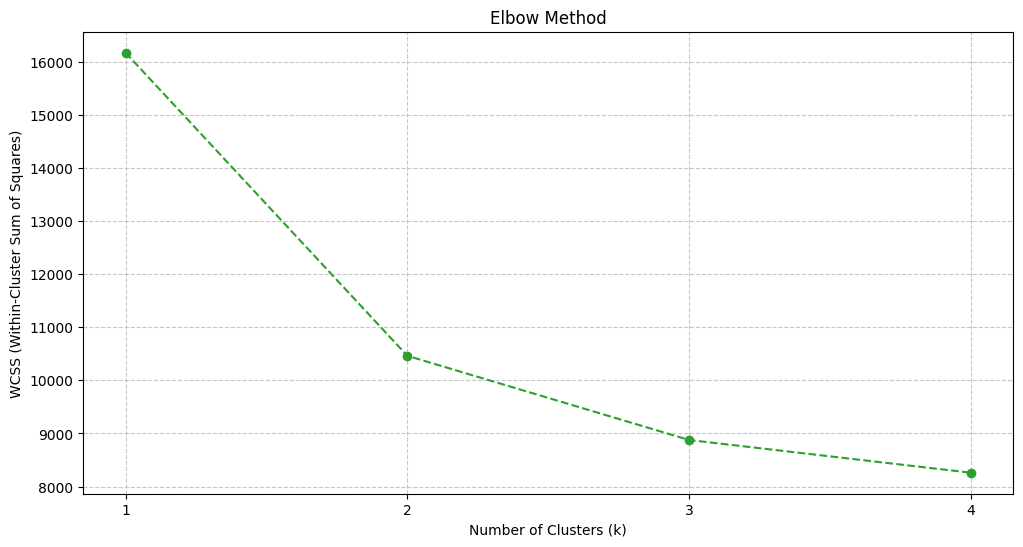

In [14]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

MAX_CLUSTERS = 4

wcss = [] 
cluster_range = range(1, MAX_CLUSTERS + 1)

for i in cluster_range:
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(12, 6))
plt.plot(cluster_range, wcss, marker='o', linestyle='--', color='#2ca02c')

plt.title('Elbow Method')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('WCSS (Within-Cluster Sum of Squares)')

if MAX_CLUSTERS <= 20:
    plt.xticks(cluster_range)
elif MAX_CLUSTERS <= 40:
    plt.xticks(range(1, MAX_CLUSTERS + 1, 2))
else:
    plt.xticks(range(1, MAX_CLUSTERS + 1, 5))

plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

The MAX_NUMBER of clusters equals 4 because of my personal observations on the test graphic which have 100-value. The mathematically ideal inflection point here is 4. It is at 4 that the maximum benefit from division ends. ![alt text](image.png)

### 3.2 Target Group Identification

We will force K-Means to split all customers into exactly 4 groups. The most important thing here is that the algorithm will return us an array with numbers from 0 to 3 for each customer. We will paste this number as a new Cluster column into our original dataframe (with real salaries and purchases, not scaled, obscure numbers), and look at the average values ​​of each group.

In [15]:
kmeans_final = KMeans(n_clusters=4, init='k-means++', random_state=42)
df['Cluster'] = kmeans_final.fit_predict(X_scaled)

profiling_columns = [
    'Income', 
    'MntTotal', 
    'NumDealsPurchases', 
    'NumStorePurchases', 
    'NumWebPurchases',
    'Customer_Days'
]

cluster_profile = df.groupby('Cluster')[profiling_columns].mean().round(1)

cluster_profile['Cluster_Size'] = df.groupby('Cluster').size()

display(cluster_profile)

,Income,MntTotal,NumDealsPurchases,NumStorePurchases,NumWebPurchases,Customer_Days,Cluster_Size
Cluster,,,,,,,
0,33957.6,73.9,1.9,3.2,2.0,2471.5,888
1,76057.1,1423.5,1.4,8.4,5.6,2607.4,397
2,67459.3,804.1,1.8,8.5,5.3,2383.8,397
3,51119.8,558.8,5.2,6.7,6.5,2654.2,339


 + Cluster 0 ("Casual/Low-Activity Buyers"): The largest group (888 people). They have the lowest income (~33k) and spend abysmally—just $73.9 million over two years. These are the random people who come in, buy a couple of times, and disappear.

 + Cluster 1 ("VIP / Loyal Elite"): There are 397 of them. They have the highest income (~76k) and colossal spending ($1,423). But look at NumDealsPurchases - only 1.4! They don't care about discounts at all; they come for quality (organic loyalty) and buy everything in physical stores (8.4).

 + Cluster 2 ("Promising Middle Class"): High income, high spending ($804). Similar to VIP, but these are the most "new" clients (Customer_Days = 2383).

 + Cluster 3 ("Bargain Hunters"): Average income (~51k), average spending. But look at the discounts: 5.2% of purchases are on sale! These are absolute record-breakers. They're just waiting for promotions.

So we can make 2 groups:

**Group A (Brand/Quality Loyal)**: Cluster 1. They hardly react to discounts.
**Group B (Random/Disloyal)**: Cluster 0 (or Cluster 3, as prominent representatives of promotional buyers).

In [16]:
df['Total_Purchases'] = df['NumStorePurchases'] + df['NumWebPurchases'] + df['NumCatalogPurchases']

df['Deal_Ratio'] = df['NumDealsPurchases'] / (df['Total_Purchases'] + 0.001)

random_buyers = df[df['Cluster'] == 0]['Deal_Ratio']
loyal_buyers = df[df['Cluster'] == 1]['Deal_Ratio']

print(f"Discount-Sales ratio (Random Buyers): {random_buyers.mean() * 100:.1f}%")
print(f"Discount-Sales ratio (Loyal Buyers): {loyal_buyers.mean() * 100:.1f}%")

from scipy import stats
stat, p_value = stats.shapiro(random_buyers)
print(f"\np-value of the Shapiro-Wilk test: {p_value}")
if p_value > 0.05:
    print("Distribution is normal -> Using T-test")
else:
    print("Distribution is not normal -> Using Mann-Whitney U test")

Discount-Sales ratio (Random Buyers): 33.9%
Discount-Sales ratio (Loyal Buyers): 7.0%

p-value of the Shapiro-Wilk test: 9.943982534804728e-13
Distribution is not normal -> Using Mann-Whitney U test


### 4. Mathematical testing of hypothesis ***H0***

We'll use the nonparametric Mann-Whitney U test. Since our hypothesis is "Random customers make a higher proportion of discount purchases than loyal customers," we'll use a one-tailed test (alternative='greater').

In [17]:
from scipy.stats import mannwhitneyu

stat, p_value_mw = mannwhitneyu(random_buyers, loyal_buyers, alternative='greater')

print(f"Mann-Whitney U statistic: {stat}")
print(f"p-value: {p_value_mw}")

print("-" * 50)
if p_value_mw < 0.05:
    print("Result: Rejecting the null hypothesis (H0).")
    print("Conclusion: Random buyers statistically significantly more often make purchases due to discounts and advertising than loyal customers.")
else:
    print("Result: No significant evidence to reject the null hypothesis (H0).")

Mann-Whitney U statistic: 344444.0
p-value: 1.5234927524395199e-165
--------------------------------------------------
Result: Rejecting the null hypothesis (H0).
Conclusion: Random buyers statistically significantly more often make purchases due to discounts and advertising than loyal customers.


## 5. General Conclusions & Business Insights

During the execution of this project, an extensive analysis of the Customer Personality Analysis dataset was conducted. The primary objective was not only to explore the underlying data structure but also to mathematically validate the effectiveness of retention strategies across different customer segments.

### 5.1. Machine Learning Results (Customer Segmentation)
* The dataset was successfully cleaned of missing values (`NaN`), zero-variance features, and anomalous outliers (e.g., Age > 100).
* Using the **K-Means** clustering algorithm, optimized via the **Elbow Method**, the customer base was partitioned into $k=4$ distinct clusters.
* Cluster profiling allowed us to identify polar groups: the **"Loyal Elite"** (characterized by high income and stable, full-price purchases) and **"Occasional/Random Buyers"** (characterized by lower overall spending and a strong focus on promotional offers).

### 5.2. Statistical Hypothesis Testing (Inference)
* **Alternative Hypothesis ($H_1$):** Occasional buyers make a statistically significantly larger proportion of their purchases due to discounts and promotions compared to loyal customers.
* Distribution analysis using the **Shapiro-Wilk test** demonstrated that the target metric has a highly skewed, non-normal distribution ($p \approx 9.94 \times 10^{-13}$). 
* Consequently, the non-parametric **Mann-Whitney U test** was selected for hypothesis testing. The resulting $p$-value of $\approx 1.52 \times 10^{-165}$ allows us to confidently **reject the null hypothesis ($H_0$)**.

### 5.3. Key Business Insight & Strategy
The analysis confirmed a colossal difference in consumer behavior: the proportion of discount-driven purchases among "Occasional Buyers" is **33.9%**, whereas for the "Loyal Elite" it is a mere **7.0%**.

**Resolution of the Research Problem:** It has been mathematically proven that occasional and low-activity buyers cannot be effectively retained by appealing to organic product quality or brand loyalty. The only statistically validated and effective strategy for retaining this segment and stimulating their purchases relies on **targeted marketing campaigns and aggressive promotional discounts**. 

Conversely, offering regular discounts to the "Loyal Elite" segment is highly inefficient, as it simply erodes profit margins without yielding any significant increase in their purchasing activity.